# (8) Effective CosmoHydro_emu parameters that reproduce Frontier-E

**Context.** nb6/nb7 and `investigations/cosmohydro_gsmf_excess/REPORT.md` established that the
400 h⁻¹Mpc suite behind `cosmohydro_emu` was run with a *different CRK-HACC code state* (newer
build, `SF_FULL_SFR` on, `CHEM_USE_INIT_STAR_MASS` off, weaker black-hole growth) than the
128 h⁻¹Mpc subgrid suite, Frontier-E-Small and Frontier-E. The subgrid parameters therefore do
not mean the same thing in the two models: at the nominal Frontier-E values, CosmoHydro_emu
over-predicts the massive end of the GSMF by 0.1-0.2 dex and under-suppresses P(k) by a few
percent (nb1 figure 1, nb4). This is not something a re-run fixes; it is a re-interpretation.

**Goal.** Find the set of CosmoHydro_emu subgrid parameters
(κ_w, e_w, M_seed, v_kin, ε_kin) — cosmology fixed to Frontier-E — whose emulated statistics
match the **Frontier-E family of simulations** (old code state): the survey-scale Frontier-E run
where it exists (P(k) ratio at four redshifts, the z = 0 GSMF) and Frontier-E-Small otherwise
(GSMF at z = 0.5, 1; f_gas, cluster gas density profile, cosmic SFR history). No observational
data are used. The result is an "effective Frontier-E point" for CosmoHydro_emu, with its
uncertainty and degeneracies, plus a check on statistics and redshifts that were not fitted.

| statistic | target | z used in the fit | error model |
|---|---|---|---|
| GSMF | survey-scale Frontier-E (z = 0), Frontier-E-Small (z = 0.5, 1) | 0, 0.5, 1 | Poisson ⊕ 3 % (survey) / 5 % (Small) ⊕ GP std, in log |
| P_hydro/P_GO | survey-scale Frontier-E, k = 0.05-10 h Mpc⁻¹ in 40 log bins | 0, 0.5, 1, 2 | 1 % ⊕ GP std |
| f_gas(M₅₀₀c) | Frontier-E-Small (3 emulator masses) | 0 | 0.01 ⊕ GP std |
| ρ_gas/ρ_crit(r/R₅₀₀c) | Frontier-E-Small (19 radii) | 0 | 10 % ⊕ GP std, in log |
| CSFR(a) | Frontier-E-Small, a = 0.25-1 in 30 bins | z = 0 history | 10 % ⊕ GP std, in log |

Objective: J(p) = Σ_s χ²_s(p) / N_s (each statistic weighted equally). Held out for
cross-checks: GSMF at z = 0.1, 0.25, 2; P(k) ratio at z = 0.25, 1.5; f_gas and CGD at z = 0.5.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

import cosmohydro_emu as ce
import subgrid_emu as sge

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params(); h = FP['h']
P5_NOM = np.array([FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin_sim'], FP['epsilon_kin']])
COSMO = np.array([FP['omega_m'], FP['sigma_8']])
NAMES = ['kappa_w', 'e_w', 'M_seed/1e6', 'v_kin/1e4', 'eps_kin/10']
LAT = [r'$\kappa_w$', r'$e_w$', r'$M_{seed}/10^6$', r'$v_{kin}/10^4$', r'$\epsilon_{kin}/10$']
LO = np.array([2.0, 0.2, 0.6, 0.1, 0.02]); HI = np.array([4.0, 1.0, 2.0, 1.2, 1.2])   # CosmoHydro training box

E = {n: ce.load_emulator(n) for n in ['GSMF', 'Pk-ratio', 'fGas', 'CGD', 'CSFR']}
XG = {n: np.asarray(ce.get_x_grid(n)[0]) for n in E}
def emu(name, p5, z=0.0):
    m, s = E[name].predict(list(p5) + list(COSMO), z=z, check_bounds=False)
    return np.asarray(m), np.asarray(s)

FES = '../data_sims/frontier_e_small'          # Frontier-E-Small HAVOCC extracts (copied from extract_14.6)
FE = '../data_sims/frontier_e'                 # survey-scale Frontier-E power spectra + galaxy-catalog histograms
STEP_Z = {624: 0.0, 567: 0.1, 498: 0.25, 415: 0.5, 310: 1.0, 247: 1.5, 205: 2.0}
print('nominal Frontier-E subgrid point:', dict(zip(NAMES, P5_NOM)), ' cosmology', COSMO)

nominal Frontier-E subgrid point: {'kappa_w': 3.0, 'e_w': 0.5, 'M_seed/1e6': 0.8, 'v_kin/1e4': 0.51, 'eps_kin/10': 0.13}  cosmology [0.14176 0.8102 ]


## 1. Targets from the Frontier-E family

In [3]:
x_g = XG['GSMF']; lx = np.log10(x_g); dlog_g = np.diff(lx)[0]
L10 = lambda a: np.log10(np.where(a > 0, a, np.nan))

# --- survey-scale Frontier-E GSMF at z = 0 (nb6 section E: three portal queries stitched, normalised by their overlaps)
H = {k: np.load(f'{FE}/catalogs/frontier_e_z0_mstar_{k}_hist.npz') for k in ['gt3e9_subsample', 'gt2e11_subsample', 'gt1e12_complete']}
e_all = H['gt3e9_subsample']['log10_edges']; lo_all = e_all[:-1]; Lbox = float(H['gt1e12_complete']['box']); dfine = e_all[1] - e_all[0]
def on_all(k):
    c = np.zeros(len(lo_all)); e = H[k]['log10_edges']; i = np.searchsorted(lo_all, e[0] - 1e-9); c[i:i + len(H[k]['counts'])] = H[k]['counts']; return c
c9, c11, c12 = on_all('gt3e9_subsample'), on_all('gt2e11_subsample'), on_all('gt1e12_complete')
ov12 = (lo_all >= 12.0) & (c12 > 0); f11 = c11[ov12].sum() / c12[ov12].sum()
ov11 = (lo_all >= np.log10(2e11) + 1e-9) & (lo_all < 12.0) & (c11 > 0); f9 = c9[ov11].sum() / (c11[ov11].sum() / f11)
src = np.where(lo_all >= 12.0, 2, np.where(lo_all >= np.log10(2e11) - 1e-9, 1, 0))
cnt_f = np.where(src == 2, c12, np.where(src == 1, c11 / f11, c9 / f9)); raw_f = np.where(src == 2, c12, np.where(src == 1, c11, c9))
# integrate the 0.02-dex histogram over the emulator's 16 bins (edges at lx ± dlog/2)
gsmf_fe0 = np.zeros(len(x_g)); raw_fe0 = np.zeros(len(x_g))
for j in range(len(x_g)):
    m = (lo_all + dfine / 2 > lx[j] - dlog_g / 2) & (lo_all + dfine / 2 < lx[j] + dlog_g / 2)
    gsmf_fe0[j] = cnt_f[m].sum() / (Lbox**3 * dlog_g); raw_fe0[j] = raw_f[m].sum()
err_fe0 = gsmf_fe0 / np.sqrt(np.maximum(raw_fe0, 1))

def read_gsmf_fes(step):
    d = np.loadtxt(f'{FES}/GalStellarMassFunction_{step}.txt'); m = (d[:, 0] > 5e9) & (d[:, 0] < 3e11)
    assert np.allclose(d[m, 0], x_g); return d[m, 1], d[m, 2]
def read_pk_ratio_fe(step):
    a = np.loadtxt(f'{FE}/pk_hydro/m000p.pk.{step}'); b = np.loadtxt(f'{FE}/pk_gravonly/m000p.pk.{step}')
    r = a[:, 1] / np.interp(np.log(a[:, 0]), np.log(b[:, 0]), b[:, 1]); return a[:, 0], r
def read_fgas_fes(step):
    d = np.loadtxt(f'{FES}/Mgas_M500_Ratio_{step}.txt'); ok = d[:, 3] > 0
    return np.interp(np.log10(XG['fGas']), d[ok, 0], d[ok, 3]), np.interp(np.log10(XG['fGas']), d[ok, 0], d[ok, 4])
def read_cgd_fes(step):
    # log-log interpolation onto the emulator radii (the extract's finite rows differ slightly between steps)
    d = np.loadtxt(f'{FES}/ClusterGasDensityProfile_{step}.txt'); ok = np.isfinite(d[:, 1]) & (d[:, 1] > 0)
    lr = np.log10(XG['CGD'])
    return tuple(10**np.interp(lr, d[ok, 0], np.log10(np.maximum(d[ok, c], 1e-30))) for c in (1, 2, 3))
csfr_fes = np.loadtxt(f'{FES}/CSFR.txt')

# --- P(k) ratio targets on 40 log bins in k = 0.05-10 h/Mpc, on the emulator k grid
k_emu = XG['Pk-ratio']; KB = np.logspace(np.log10(0.05), 1.0, 41); KC = np.sqrt(KB[1:] * KB[:-1])
def to_kbins(k, y):
    idx = np.digitize(k, KB) - 1; return np.array([np.mean(y[idx == i]) for i in range(len(KC))])
# --- CSFR bins in a = 0.25-1 (z <= 3)
AB = np.linspace(0.25, 1.0, 31); AC = 0.5 * (AB[1:] + AB[:-1])
def to_abins(a, y):
    idx = np.digitize(a, AB) - 1; return np.array([np.mean(y[idx == i]) if np.any(idx == i) else np.nan for i in range(len(AC))])

# target table: name -> dict(kind, z, y, sig, extra)
T = {}
T['GSMF z=0'] = dict(stat='GSMF', z=0.0, kind='log', y=gsmf_fe0, sig=np.sqrt((err_fe0 / gsmf_fe0 / np.log(10))**2 + (0.03 / np.log(10))**2), label='Frontier-E (3150 $h^{-1}$Mpc)')
for step, z in [(415, 0.5), (310, 1.0)]:
    y, e = read_gsmf_fes(step)
    T[f'GSMF z={z}'] = dict(stat='GSMF', z=z, kind='log', y=y, sig=np.sqrt((e / y / np.log(10))**2 + (0.05 / np.log(10))**2), label='Frontier-E-Small')
for step in [624, 415, 310, 205]:
    k, r = read_pk_ratio_fe(step); z = STEP_Z[step]
    T[f'Pk-ratio z={z}'] = dict(stat='Pk-ratio', z=z, kind='lin', y=to_kbins(k, r), sig=np.full(len(KC), 0.01), label='Frontier-E (3150 $h^{-1}$Mpc)')
fg, fgs = read_fgas_fes(624)
T['fGas z=0'] = dict(stat='fGas', z=0.0, kind='lin', y=fg, sig=np.full(3, 0.01), label='Frontier-E-Small')
cg, cglo, cghi = read_cgd_fes(624)
T['CGD z=0'] = dict(stat='CGD', z=0.0, kind='log', y=cg, sig=np.full(len(cg), 0.10 / np.log(10)), label='Frontier-E-Small', lo=cglo, hi=cghi)
T['CSFR'] = dict(stat='CSFR', z=0.0, kind='log', y=to_abins(csfr_fes[:, 0], csfr_fes[:, 1]), sig=np.full(len(AC), 0.10 / np.log(10)), label='Frontier-E-Small')
FIT_KEYS = list(T)
print(f'{"target":16s} {"N":>3s}  source')
for kname, t in T.items(): print(f'{kname:16s} {len(t["y"]):3d}  {t["label"]}')
print(f'survey-scale GSMF normalisation: f(2e11 query) = {f11:.4f}, f(3e9 query) = {f9:.5f}')

def model(name, p5, z):
    m, s = emu(T[name]['stat'] if name in T else name, p5, z)
    st = T[name]['stat'] if name in T else name
    if st == 'Pk-ratio': return to_kbins(k_emu, m), to_kbins(k_emu, s)
    if st == 'CSFR':     return to_abins(XG['CSFR'], m), to_abins(XG['CSFR'], s)
    return m, s

def chi2_one(name, p5):
    t = T[name]; m, s = model(name, p5, t['z'])
    if t['kind'] == 'log':
        r = L10(m) - L10(t['y']); sig = np.sqrt(t['sig']**2 + (s / np.maximum(m, 1e-30) / np.log(10))**2)
    else:
        r = m - t['y']; sig = np.sqrt(t['sig']**2 + s**2)
    ok = np.isfinite(r); return np.sum((r[ok] / sig[ok])**2), ok.sum()

def objective(p5, keys=FIT_KEYS, weights=None):
    tot = 0.0
    for kname in keys:
        c, n = chi2_one(kname, p5); w = 1.0 if weights is None else weights.get(kname, 1.0)
        tot += w * c / n
    return tot

target             N  source
GSMF z=0          16  Frontier-E (3150 $h^{-1}$Mpc)
GSMF z=0.5        16  Frontier-E-Small
GSMF z=1.0        16  Frontier-E-Small
Pk-ratio z=0.0    40  Frontier-E (3150 $h^{-1}$Mpc)
Pk-ratio z=0.5    40  Frontier-E (3150 $h^{-1}$Mpc)
Pk-ratio z=1.0    40  Frontier-E (3150 $h^{-1}$Mpc)
Pk-ratio z=2.0    40  Frontier-E (3150 $h^{-1}$Mpc)
fGas z=0           3  Frontier-E-Small
CGD z=0           19  Frontier-E-Small
CSFR              30  Frontier-E-Small
survey-scale GSMF normalisation: f(2e11 query) = 0.4968, f(3e9 query) = 0.00622


## 2. Baseline: CosmoHydro_emu at the nominal Frontier-E parameters

In [4]:
def chi2_table(points, keys=FIT_KEYS):
    print(f'{"chi2/N":16s} ' + ' '.join(f'{n:>14s}' for n in points))
    tot = {n: 0.0 for n in points}
    for kname in keys:
        row = []
        for n, p in points.items():
            c, N = chi2_one(kname, p); row.append(c / N); tot[n] += c / N
        print(f'{kname:16s} ' + ' '.join(f'{v:14.2f}' for v in row))
    print(f'{"sum (= J)":16s} ' + ' '.join(f'{tot[n]:14.2f}' for n in points))
    return tot

t0 = time.time(); J_nom = objective(P5_NOM); print(f'J(nominal) = {J_nom:.2f}   ({time.time() - t0:.2f} s per objective evaluation)')
chi2_table({'nominal FE': P5_NOM});

J(nominal) = 73.39   (0.29 s per objective evaluation)
chi2/N               nominal FE
GSMF z=0                  41.17
GSMF z=0.5                 9.59
GSMF z=1.0                 6.79
Pk-ratio z=0.0             1.11
Pk-ratio z=0.5             2.62
Pk-ratio z=1.0             1.40
Pk-ratio z=2.0             0.04
fGas z=0                   0.18
CGD z=0                    9.55
CSFR                       0.95
sum (= J)                 73.39


## 3. Which parameters can each statistic constrain?

Finite-difference sensitivity at the nominal point: RMS over the data points of
∂(log₁₀ or linear statistic)/∂(p / box width), i.e. the change across the full training
range of each parameter. Compared with the error budget, this shows which parameters are
constrained by which statistic and which are degenerate.

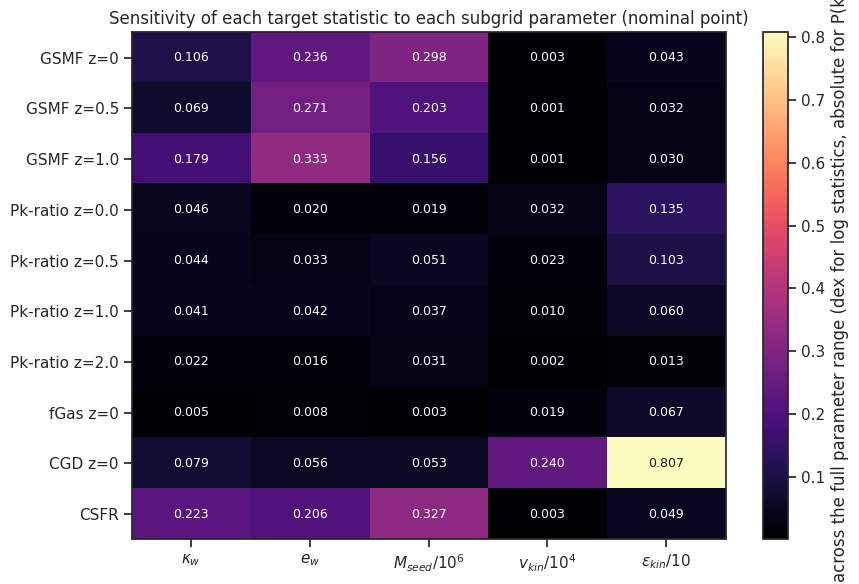

typical per-point error budget: GSMF 0.02-0.03 dex, Pk-ratio 0.01, fGas 0.01, CGD 0.04 dex, CSFR 0.04 dex


In [5]:
def resid_vec(p5):
    out = {}
    for kname in FIT_KEYS:
        t = T[kname]; m, _ = model(kname, p5, t['z'])
        out[kname] = L10(m) if t['kind'] == 'log' else m
    return out
base = resid_vec(P5_NOM); S = np.zeros((len(FIT_KEYS), 5))
for i in range(5):
    dp = 0.05 * (HI[i] - LO[i]); p = P5_NOM.copy(); p[i] += dp
    pert = resid_vec(p)
    for j, kname in enumerate(FIT_KEYS):
        d = (pert[kname] - base[kname]) / dp * (HI[i] - LO[i]); S[j, i] = np.sqrt(np.nanmean(d**2))
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(S, cmap='magma', aspect='auto')
ax.set_xticks(range(5)); ax.set_xticklabels(LAT); ax.set_yticks(range(len(FIT_KEYS))); ax.set_yticklabels(FIT_KEYS)
for j in range(len(FIT_KEYS)):
    for i in range(5): ax.text(i, j, f'{S[j, i]:.3f}', ha='center', va='center', color='w' if S[j, i] < 0.6 * S.max() else 'k', fontsize=9)
plt.colorbar(im, label='RMS change across the full parameter range (dex for log statistics, absolute for P(k) ratio / f_gas)')
ax.set_title('Sensitivity of each target statistic to each subgrid parameter (nominal point)'); plt.tight_layout(); plt.show()
print('typical per-point error budget: GSMF 0.02-0.03 dex, Pk-ratio 0.01, fGas 0.01, CGD 0.04 dex, CSFR 0.04 dex')

## 4. Joint fit over the five subgrid parameters (cosmology fixed)

Differential evolution inside the training box (global), then a local polish. Per-statistic
fits (Powell, started from the nominal point and from the joint solution) show what each
statistic alone would ask for and where the trade-offs are.

In [6]:
rng_seed = 7
t0 = time.time()
de = differential_evolution(objective, bounds=list(zip(LO, HI)), seed=rng_seed, popsize=8, maxiter=35, tol=1e-3, polish=False, init='latinhypercube')
pol = minimize(objective, de.x, method='Powell', bounds=list(zip(LO, HI)), options={'xtol': 1e-3, 'ftol': 1e-4, 'maxfev': 400})
P5_FIT = pol.x if pol.fun < de.fun else de.x; J_fit = min(pol.fun, de.fun)
print(f'differential evolution: J = {de.fun:.3f} after {de.nfev} evaluations; Powell polish: J = {pol.fun:.3f} ({time.time() - t0:.0f} s)')
print('joint best fit:', dict(zip(NAMES, np.round(P5_FIT, 3))))
print('nominal       :', dict(zip(NAMES, P5_NOM)))
at_edge = [NAMES[i] for i in range(5) if (P5_FIT[i] - LO[i]) < 0.02 * (HI[i] - LO[i]) or (HI[i] - P5_FIT[i]) < 0.02 * (HI[i] - LO[i])]
print('parameters within 2 % of the box edge:', at_edge if at_edge else 'none')
tot = chi2_table({'nominal FE': P5_NOM, 'joint fit': P5_FIT})

differential evolution: J = 12.829 after 1440 evaluations; Powell polish: J = 12.654 (224 s)
joint best fit: {'kappa_w': 3.008, 'e_w': 0.549, 'M_seed/1e6': 0.939, 'v_kin/1e4': 0.347, 'eps_kin/10': 1.2}
nominal       : {'kappa_w': 3.0, 'e_w': 0.5, 'M_seed/1e6': 0.8, 'v_kin/1e4': 0.51, 'eps_kin/10': 0.13}
parameters within 2 % of the box edge: ['eps_kin/10']
chi2/N               nominal FE      joint fit
GSMF z=0                  41.17           5.55
GSMF z=0.5                 9.59           0.43
GSMF z=1.0                 6.79           0.75
Pk-ratio z=0.0             1.11           0.18
Pk-ratio z=0.5             2.62           0.77
Pk-ratio z=1.0             1.40           0.32
Pk-ratio z=2.0             0.04           0.68
fGas z=0                   0.18           0.27
CGD z=0                    9.55           2.51
CSFR                       0.95           1.20
sum (= J)                 73.39          12.65


In [7]:
GROUPS = {'GSMF (3 z)': [k for k in FIT_KEYS if k.startswith('GSMF')], 'Pk-ratio (4 z)': [k for k in FIT_KEYS if k.startswith('Pk')],
          'fGas': ['fGas z=0'], 'CGD': ['CGD z=0'], 'CSFR': ['CSFR']}
PER = {}
t0 = time.time()
for g, keys in GROUPS.items():
    best = None
    for start in [P5_NOM, P5_FIT]:
        r = minimize(lambda p: objective(p, keys), start, method='Powell', bounds=list(zip(LO, HI)), options={'xtol': 1e-3, 'ftol': 1e-4, 'maxfev': 300})
        if best is None or r.fun < best.fun: best = r
    PER[g] = best.x
print(f'per-statistic fits done ({time.time() - t0:.0f} s)\n')
print(f'{"fit to":16s} ' + ' '.join(f'{n:>11s}' for n in NAMES) + '   J(all)')
print(f'{"nominal":16s} ' + ' '.join(f'{v:11.3f}' for v in P5_NOM) + f'   {objective(P5_NOM):7.2f}')
print(f'{"joint":16s} ' + ' '.join(f'{v:11.3f}' for v in P5_FIT) + f'   {objective(P5_FIT):7.2f}')
for g, p in PER.items(): print(f'{g:16s} ' + ' '.join(f'{v:11.3f}' for v in p) + f'   {objective(p):7.2f}')
print('\nchi2/N of every target at each per-statistic optimum (rows) -- off-diagonal blocks show the trade-offs')
chi2_table({**{'nominal': P5_NOM, 'joint': P5_FIT}, **{g[:10]: p for g, p in PER.items()}});

per-statistic fits done (59 s)

fit to               kappa_w         e_w  M_seed/1e6   v_kin/1e4  eps_kin/10   J(all)
nominal                3.000       0.500       0.800       0.510       0.130     73.39
joint                  3.008       0.549       0.939       0.347       1.200     12.65
GSMF (3 z)             2.989       0.536       0.973       1.200       1.199     26.04
Pk-ratio (4 z)         2.104       0.373       0.749       0.450       0.122     32.50
fGas                   2.743       0.200       1.861       0.579       0.154    132.95
CGD                    2.001       0.201       1.394       1.200       0.167     89.37
CSFR                   3.042       0.505       0.823       0.100       0.896     36.22

chi2/N of every target at each per-statistic optimum (rows) -- off-diagonal blocks show the trade-offs
chi2/N                  nominal          joint     GSMF (3 z)     Pk-ratio (           fGas            CGD           CSFR
GSMF z=0                  41.17           5.55 

## 5. Emulator at the effective point vs the Frontier-E targets

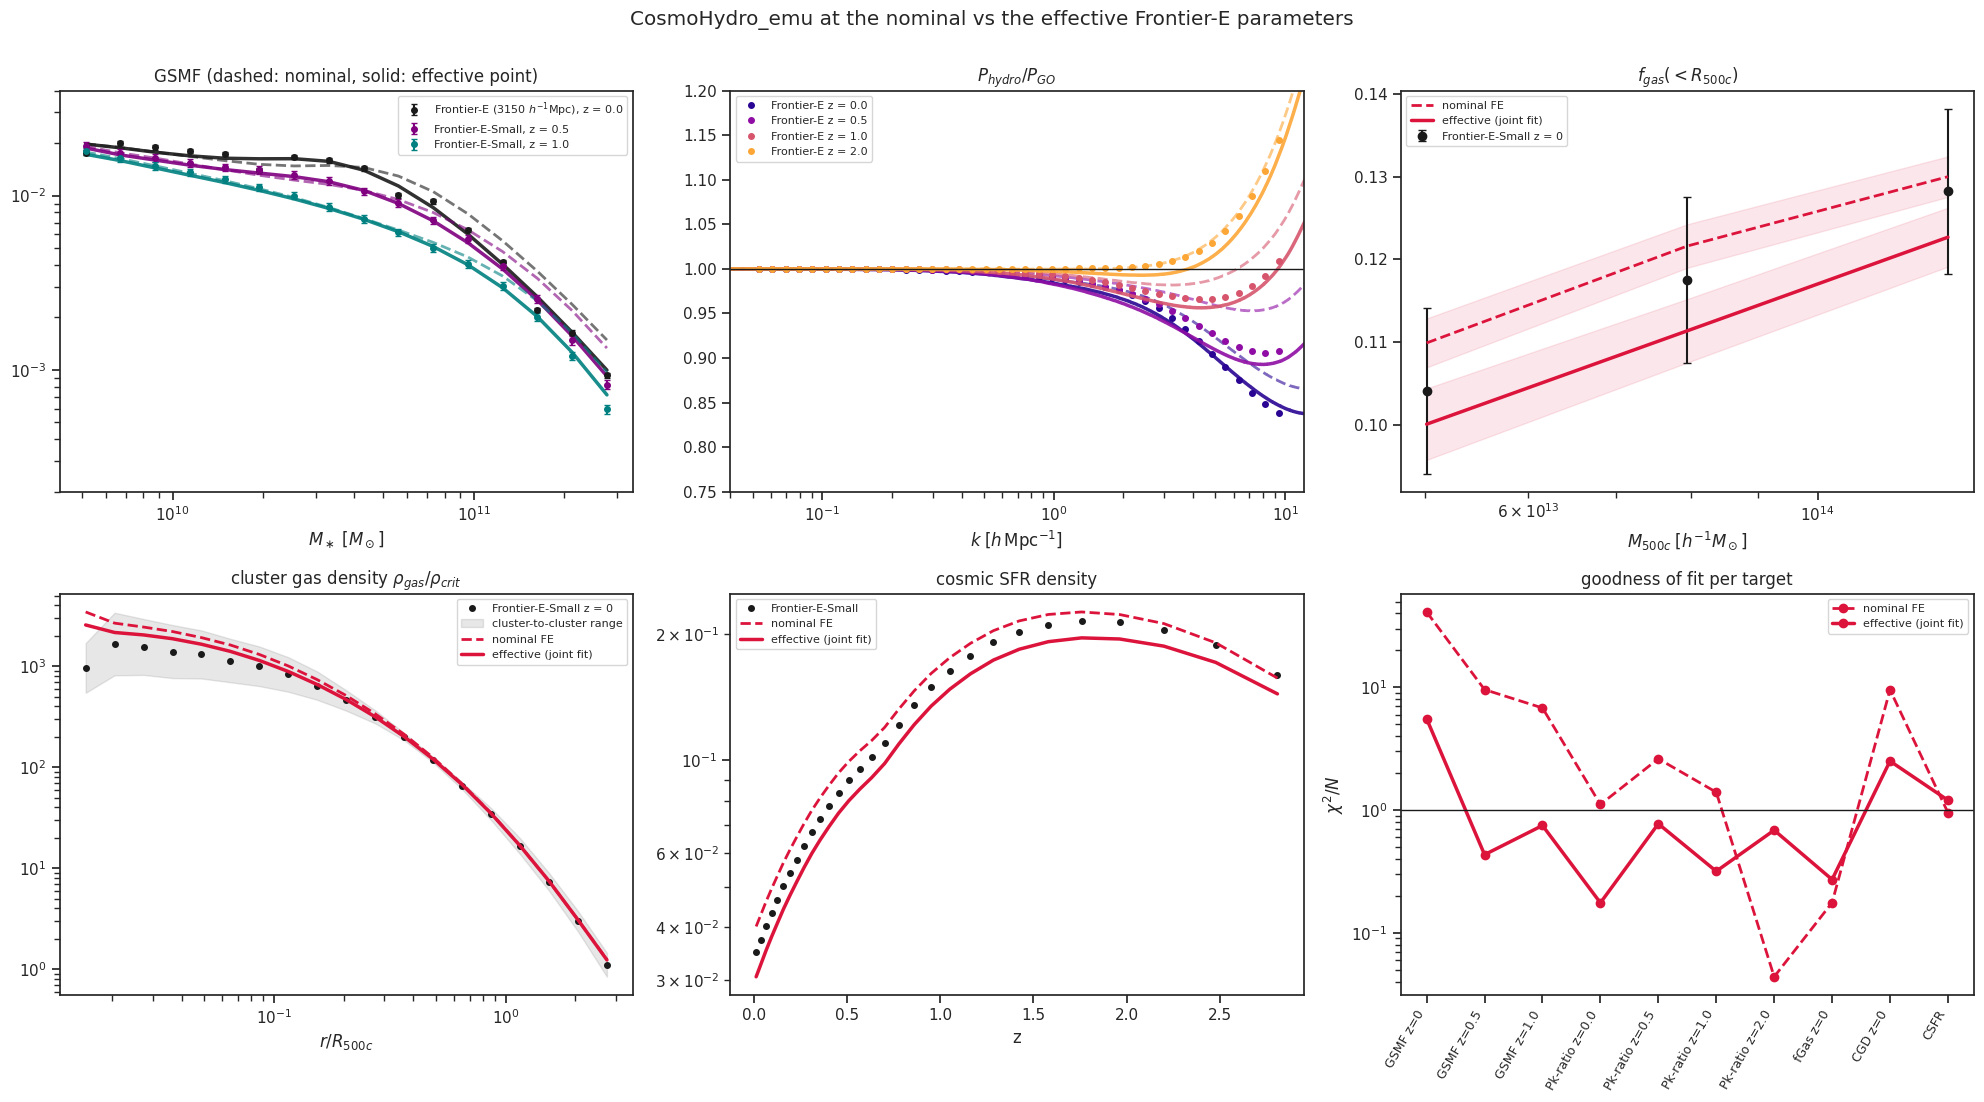

In [8]:
def plot_all(points, title):
    fig, axes = plt.subplots(2, 3, figsize=(20, 11)); axes = axes.ravel()
    styles = {n: s for n, s in zip(points, [('crimson', '--', 2), ('crimson', '-', 2.5), ('steelblue', '-', 2), ('gray', ':', 2)])}
    # GSMF
    ax = axes[0]; zc = {0.0: 'k', 0.5: 'purple', 1.0: 'teal'}
    for kname in ['GSMF z=0', 'GSMF z=0.5', 'GSMF z=1.0']:
        t = T[kname]; ax.errorbar(x_g, t['y'], yerr=t['y'] * t['sig'] * np.log(10), fmt='o', ms=4, color=zc[t['z']], capsize=2, label=f"{t['label']}, z = {t['z']}")
        for n, p in points.items():
            c, ls, lw = styles[n]; m, _ = emu('GSMF', p, t['z']); ax.plot(x_g, m, color=zc[t['z']], ls=ls, lw=lw, alpha=0.9 if ls == '-' else 0.6)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(2e-4, 4e-2); ax.set_title('GSMF (dashed: nominal, solid: effective point)'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.legend(fontsize=8)
    # Pk ratio
    ax = axes[1]; zc = plt.cm.plasma(np.linspace(0.05, 0.8, 4))
    for (kname, c) in zip(['Pk-ratio z=0.0', 'Pk-ratio z=0.5', 'Pk-ratio z=1.0', 'Pk-ratio z=2.0'], zc):
        t = T[kname]; ax.plot(KC, t['y'], 'o', ms=4, color=c, label=f"Frontier-E z = {t['z']}")
        for n, p in points.items():
            _, ls, lw = styles[n]; m, _ = emu('Pk-ratio', p, t['z']); ax.plot(k_emu, m, color=c, ls=ls, lw=lw, alpha=0.9 if ls == '-' else 0.6)
    ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.04, 12); ax.set_ylim(0.75, 1.2); ax.set_title(r'$P_{hydro}/P_{GO}$'); ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$'); ax.legend(fontsize=8)
    # fGas
    ax = axes[2]; t = T['fGas z=0']
    ax.errorbar(XG['fGas'], t['y'], yerr=t['sig'], fmt='o', ms=6, color='k', capsize=3, label='Frontier-E-Small z = 0')
    for n, p in points.items():
        c, ls, lw = styles[n]; m, s = emu('fGas', p, 0.0); ax.plot(XG['fGas'], m, color=c, ls=ls, lw=lw, label=n); ax.fill_between(XG['fGas'], m - 2*s, m + 2*s, color=c, alpha=0.1)
    ax.set_xscale('log'); ax.set_title(r'$f_{gas}(<R_{500c})$'); ax.set_xlabel(r'$M_{500c}\;[h^{-1}M_\odot]$'); ax.legend(fontsize=8)
    # CGD
    ax = axes[3]; t = T['CGD z=0']
    ax.plot(XG['CGD'], t['y'], 'o', ms=4, color='k', label='Frontier-E-Small z = 0'); ax.fill_between(XG['CGD'], t['lo'], t['hi'], color='k', alpha=0.1, label='cluster-to-cluster range')
    for n, p in points.items():
        c, ls, lw = styles[n]; m, _ = emu('CGD', p, 0.0); ax.plot(XG['CGD'], m, color=c, ls=ls, lw=lw, label=n)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title(r'cluster gas density $\rho_{gas}/\rho_{crit}$'); ax.set_xlabel(r'$r/R_{500c}$'); ax.legend(fontsize=8)
    # CSFR
    ax = axes[4]; t = T['CSFR']
    ax.plot(1/AC - 1, t['y'], 'o', ms=4, color='k', label='Frontier-E-Small')
    for n, p in points.items():
        c, ls, lw = styles[n]; m, _ = model('CSFR', p, 0.0); ax.plot(1/AC - 1, m, color=c, ls=ls, lw=lw, label=n)
    ax.set_yscale('log'); ax.set_title('cosmic SFR density'); ax.set_xlabel('z'); ax.legend(fontsize=8)
    # residual summary
    ax = axes[5]
    for n, p in points.items():
        c, ls, lw = styles[n]; vals = [chi2_one(k, p)[0] / chi2_one(k, p)[1] for k in FIT_KEYS]
        ax.plot(range(len(FIT_KEYS)), vals, 'o-', color=c, ls=ls, lw=lw, label=n)
    ax.set_xticks(range(len(FIT_KEYS))); ax.set_xticklabels(FIT_KEYS, rotation=60, ha='right', fontsize=9); ax.set_yscale('log'); ax.set_ylabel(r'$\chi^2/N$'); ax.axhline(1, color='k', lw=1); ax.set_title('goodness of fit per target'); ax.legend(fontsize=8)
    plt.suptitle(title, y=1.0); plt.tight_layout(); plt.show()

plot_all({'nominal FE': P5_NOM, 'effective (joint fit)': P5_FIT}, 'CosmoHydro_emu at the nominal vs the effective Frontier-E parameters')

## 6. Uncertainty and degeneracies of the effective point

An adaptive Metropolis chain on exp(−J/2) (J = Σ χ²/N, so this is an *effective* likelihood in
which every statistic carries the weight of one data point; the absolute error scale is set
by the floors in the table above). It gives the range of parameter sets that reproduce
Frontier-E equally well and shows the degeneracy directions.

2500 steps in 234 s, acceptance 0.19

parameter     nominal  joint fit   median      16%      84%   box
kappa_w         3.000      3.008    2.961    2.808    3.113   [2.0, 4.0]
e_w             0.500      0.549    0.518    0.480    0.561   [0.2, 1.0]
M_seed/1e6      0.800      0.939    1.170    1.031    1.263   [0.6, 2.0]
v_kin/1e4       0.510      0.347    0.668    0.396    1.017   [0.1, 1.2]
eps_kin/10      0.130      1.200    0.253    0.187    0.597   [0.02, 1.2]
J: best 11.27, posterior median 15.70

posterior correlation matrix:
              kappa_w       e_w M_seed/1e v_kin/1e4 eps_kin/1
kappa_w          1.00      0.41      0.02      0.09      0.15
e_w              0.41      1.00     -0.46     -0.26      0.41
M_seed/1e6       0.02     -0.46      1.00      0.50     -0.77
v_kin/1e4        0.09     -0.26      0.50      1.00     -0.61
eps_kin/10       0.15      0.41     -0.77     -0.61      1.00


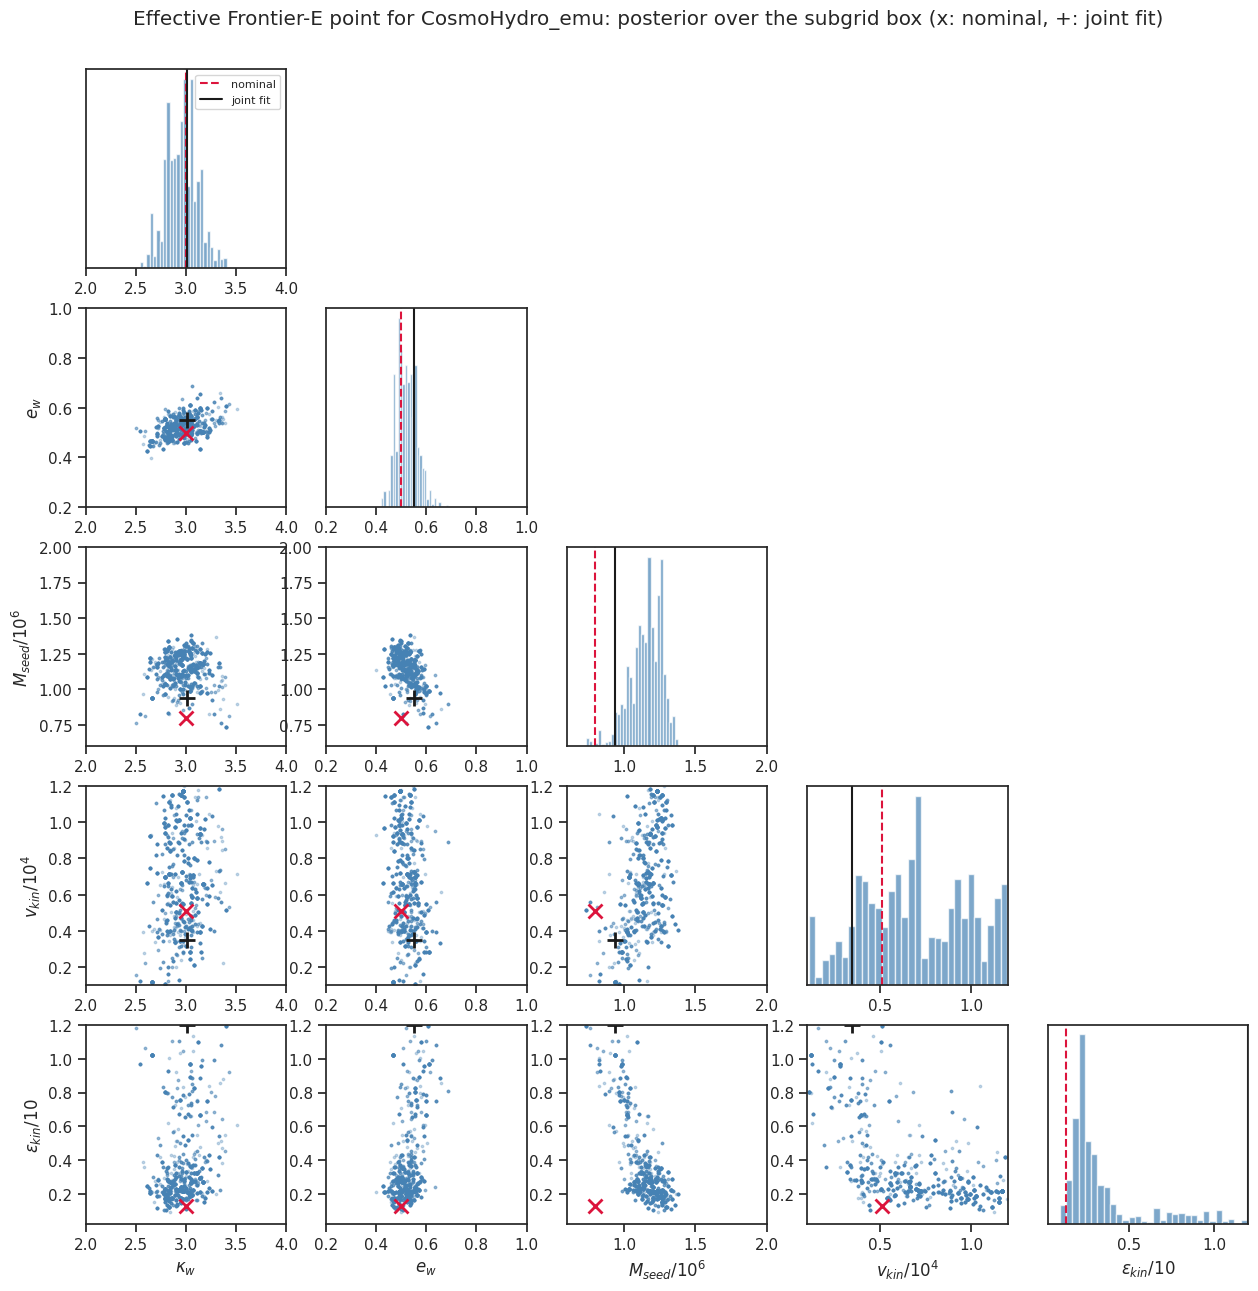

In [9]:
rng = np.random.default_rng(rng_seed)
norm = lambda p: (p - LO) / (HI - LO); denorm = lambda u: LO + u * (HI - LO)
def logpost(u):
    if np.any(u < 0) or np.any(u > 1): return -np.inf
    return -0.5 * objective(denorm(u))
N_STEPS, BURN = 2500, 500
u = norm(P5_FIT); lp = logpost(u); cov = np.diag(np.full(5, 0.03**2)); chain = np.zeros((N_STEPS, 5)); lps = np.zeros(N_STEPS); acc = 0
t0 = time.time()
for i in range(N_STEPS):
    prop = rng.multivariate_normal(u, cov); lpp = logpost(prop)
    if np.log(rng.random()) < lpp - lp: u, lp = prop, lpp; acc += 1
    chain[i] = u; lps[i] = lp
    if i >= 200 and i % 100 == 0: cov = 2.38**2 / 5 * np.cov(chain[max(0, i - 800):i].T) + np.eye(5) * 1e-6
print(f'{N_STEPS} steps in {time.time() - t0:.0f} s, acceptance {acc / N_STEPS:.2f}')
post = denorm(chain[BURN:]); Jpost = -2 * lps[BURN:]
q = np.percentile(post, [16, 50, 84], axis=0)
print(f'\n{"parameter":12s} {"nominal":>8s} {"joint fit":>10s} {"median":>8s} {"16%":>8s} {"84%":>8s}   box')
for i, n in enumerate(NAMES): print(f'{n:12s} {P5_NOM[i]:8.3f} {P5_FIT[i]:10.3f} {q[1, i]:8.3f} {q[0, i]:8.3f} {q[2, i]:8.3f}   [{LO[i]}, {HI[i]}]')
print(f'J: best {Jpost.min():.2f}, posterior median {np.median(Jpost):.2f}')
C = np.corrcoef(post.T)
print('\nposterior correlation matrix:'); print('            ' + ' '.join(f'{n[:9]:>9s}' for n in NAMES))
for i, n in enumerate(NAMES): print(f'{n[:11]:11s} ' + ' '.join(f'{C[i, j]:9.2f}' for j in range(5)))

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        if j > i: ax.axis('off'); continue
        if i == j:
            ax.hist(post[:, i], bins=30, color='steelblue', alpha=0.7); ax.axvline(P5_NOM[i], color='crimson', ls='--', label='nominal'); ax.axvline(P5_FIT[i], color='k', label='joint fit')
            ax.set_xlim(LO[i], HI[i]); ax.set_yticks([])
            if i == 0: ax.legend(fontsize=8)
        else:
            ax.scatter(post[:, j], post[:, i], s=3, alpha=0.3, color='steelblue'); ax.plot(P5_NOM[j], P5_NOM[i], 'x', color='crimson', ms=10, mew=2); ax.plot(P5_FIT[j], P5_FIT[i], '+', color='k', ms=12, mew=2)
            ax.set_xlim(LO[j], HI[j]); ax.set_ylim(LO[i], HI[i])
        if i == 4: ax.set_xlabel(LAT[j])
        if j == 0 and i > 0: ax.set_ylabel(LAT[i])
plt.suptitle('Effective Frontier-E point for CosmoHydro_emu: posterior over the subgrid box (x: nominal, +: joint fit)', y=0.92); plt.show()

## 7. Cross-checks on statistics and redshifts that were not fitted

GSMF at z = 0.1, 0.25, 2 (Frontier-E-Small), P(k) ratio at z = 0.25 and 1.5 (survey-scale),
f_gas and the gas-density profile at z = 0.5 (Frontier-E-Small): does the effective point
also reproduce them? And the translation seen from the old-code side: Subgrid_emu at the
nominal parameters vs CosmoHydro_emu at the effective parameters, for the two statistics
both packages share at z = 0.

held-out targets:
chi2/N               nominal FE      effective  posterior med
GSMF z=0.1                13.99           0.35           0.34
GSMF z=0.25               11.71           0.42           0.40
GSMF z=2.0                 0.74           0.79           1.38
Pk-ratio z=0.25            2.09           0.36           0.36
Pk-ratio z=1.5             0.13           0.97           0.45
fGas z=0.5                 0.12           0.36           0.03
CGD z=0.5                 13.04           1.53           4.13
sum (= J)                 41.83           4.79           7.08


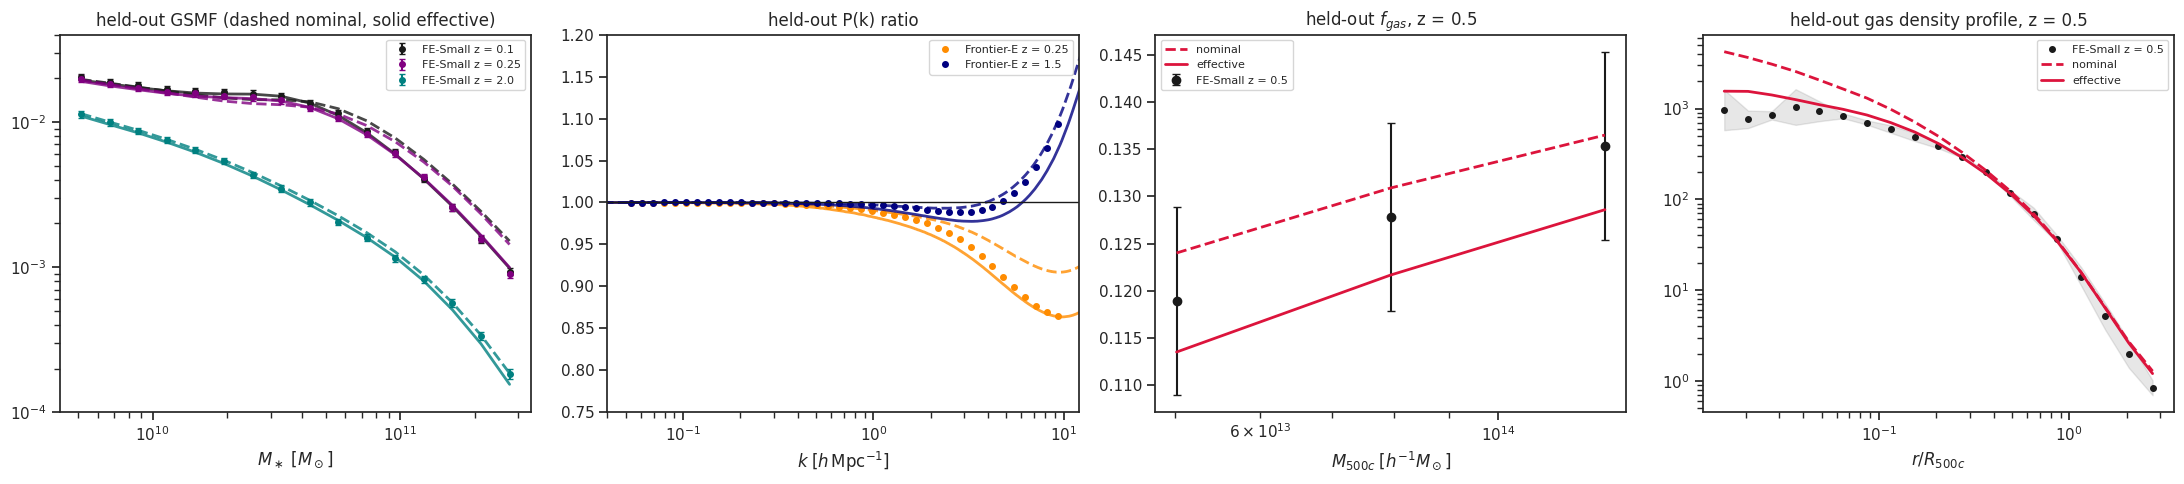

In [10]:
X = {}
for step, z in [(567, 0.1), (498, 0.25), (205, 2.0)]:
    y, e = read_gsmf_fes(step); X[f'GSMF z={z}'] = dict(stat='GSMF', z=z, kind='log', y=y, sig=np.sqrt((e / y / np.log(10))**2 + (0.05 / np.log(10))**2), label='Frontier-E-Small')
for step in [498, 247]:
    k, r = read_pk_ratio_fe(step); z = STEP_Z[step]; X[f'Pk-ratio z={z}'] = dict(stat='Pk-ratio', z=z, kind='lin', y=to_kbins(k, r), sig=np.full(len(KC), 0.01), label='Frontier-E')
fg5, _ = read_fgas_fes(415); X['fGas z=0.5'] = dict(stat='fGas', z=0.5, kind='lin', y=fg5, sig=np.full(3, 0.01), label='Frontier-E-Small')
cg5, lo5, hi5 = read_cgd_fes(415); X['CGD z=0.5'] = dict(stat='CGD', z=0.4987, kind='log', y=cg5, sig=np.full(len(cg5), 0.10 / np.log(10)), label='Frontier-E-Small', lo=lo5, hi=hi5)
T.update(X)
print('held-out targets:'); chi2_table({'nominal FE': P5_NOM, 'effective': P5_FIT, 'posterior med': q[1]}, keys=list(X))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
ax = axes[0]
for kname, c in zip(['GSMF z=0.1', 'GSMF z=0.25', 'GSMF z=2.0'], ['k', 'purple', 'teal']):
    t = T[kname]; ax.errorbar(x_g, t['y'], yerr=t['y'] * t['sig'] * np.log(10), fmt='o', ms=4, color=c, capsize=2, label=f'FE-Small z = {t["z"]}')
    for p, ls in [(P5_NOM, '--'), (P5_FIT, '-')]: m, _ = emu('GSMF', p, t['z']); ax.plot(x_g, m, color=c, ls=ls, lw=2, alpha=0.8)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-4, 4e-2); ax.set_title('held-out GSMF (dashed nominal, solid effective)'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.legend(fontsize=8)
ax = axes[1]
for kname, c in zip(['Pk-ratio z=0.25', 'Pk-ratio z=1.5'], ['darkorange', 'navy']):
    t = T[kname]; ax.plot(KC, t['y'], 'o', ms=4, color=c, label=f'Frontier-E z = {t["z"]}')
    for p, ls in [(P5_NOM, '--'), (P5_FIT, '-')]: m, _ = emu('Pk-ratio', p, t['z']); ax.plot(k_emu, m, color=c, ls=ls, lw=2, alpha=0.8)
ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.04, 12); ax.set_ylim(0.75, 1.2); ax.set_title('held-out P(k) ratio'); ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$'); ax.legend(fontsize=8)
ax = axes[2]
t = T['fGas z=0.5']; ax.errorbar(XG['fGas'], t['y'], yerr=t['sig'], fmt='o', ms=6, color='k', capsize=3, label='FE-Small z = 0.5')
for p, ls, n in [(P5_NOM, '--', 'nominal'), (P5_FIT, '-', 'effective')]: m, _ = emu('fGas', p, 0.5); ax.plot(XG['fGas'], m, color='crimson', ls=ls, lw=2, label=n)
ax.set_xscale('log'); ax.set_title(r'held-out $f_{gas}$, z = 0.5'); ax.set_xlabel(r'$M_{500c}\;[h^{-1}M_\odot]$'); ax.legend(fontsize=8)
ax = axes[3]
t = T['CGD z=0.5']; ax.plot(XG['CGD'], t['y'], 'o', ms=4, color='k', label='FE-Small z = 0.5'); ax.fill_between(XG['CGD'], t['lo'], t['hi'], color='k', alpha=0.1)
for p, ls, n in [(P5_NOM, '--', 'nominal'), (P5_FIT, '-', 'effective')]: m, _ = emu('CGD', p, 0.4987); ax.plot(XG['CGD'], m, color='crimson', ls=ls, lw=2, label=n)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title('held-out gas density profile, z = 0.5'); ax.set_xlabel(r'$r/R_{500c}$'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

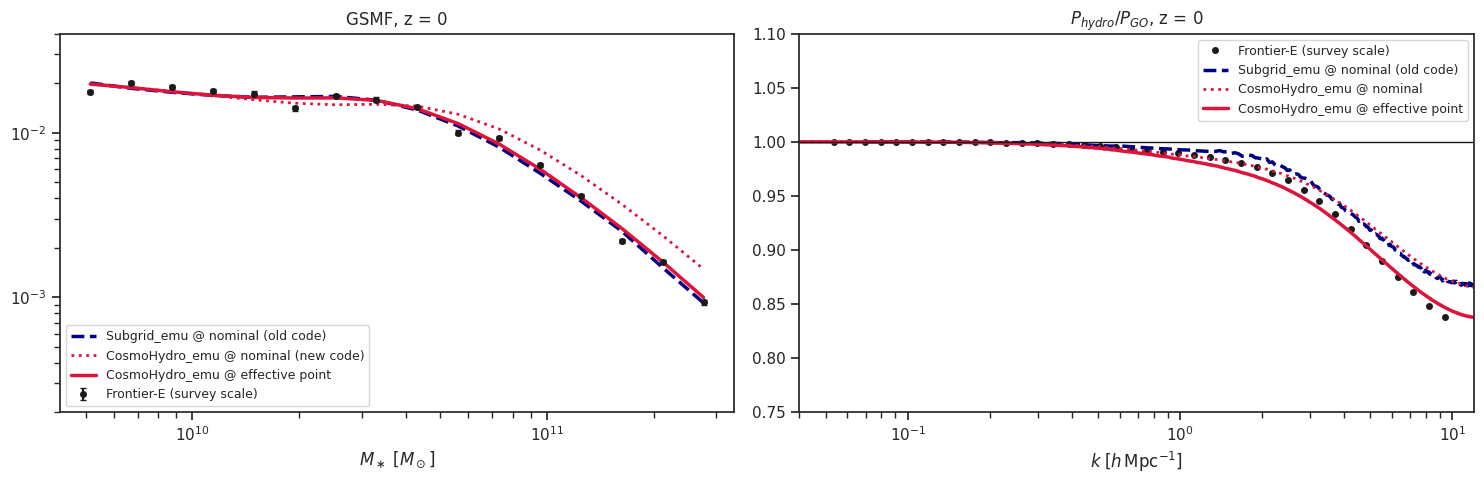

saved ../data_sims/cosmohydro_400/effective_frontier_e_point.npz


In [11]:
# the translation seen from the old-code emulator: Subgrid_emu(nominal) vs CosmoHydro_emu(effective), z = 0
sg_gsmf, _ = sge.load_emulator('GSMF').predict(list(P5_NOM)); sg_pk, _ = sge.load_emulator('Pk').predict(list(P5_NOM)); k_sg = np.asarray(sge.get_x_grid('Pk')[0])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.errorbar(x_g, T['GSMF z=0']['y'], yerr=T['GSMF z=0']['y'] * T['GSMF z=0']['sig'] * np.log(10), fmt='o', ms=4, color='k', capsize=2, label='Frontier-E (survey scale)')
ax.plot(x_g, sg_gsmf, color='navy', lw=2.5, ls='--', label='Subgrid_emu @ nominal (old code)')
ax.plot(x_g, emu('GSMF', P5_NOM, 0.0)[0], color='crimson', lw=2, ls=':', label='CosmoHydro_emu @ nominal (new code)')
ax.plot(x_g, emu('GSMF', P5_FIT, 0.0)[0], color='crimson', lw=2.5, label='CosmoHydro_emu @ effective point')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(2e-4, 4e-2); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.set_title('GSMF, z = 0'); ax.legend(fontsize=9)
ax = axes[1]
ax.plot(KC, T['Pk-ratio z=0.0']['y'], 'o', ms=4, color='k', label='Frontier-E (survey scale)')
ax.plot(k_sg, sg_pk, color='navy', lw=2.5, ls='--', label='Subgrid_emu @ nominal (old code)')
ax.plot(k_emu, emu('Pk-ratio', P5_NOM, 0.0)[0], color='crimson', lw=2, ls=':', label='CosmoHydro_emu @ nominal')
ax.plot(k_emu, emu('Pk-ratio', P5_FIT, 0.0)[0], color='crimson', lw=2.5, label='CosmoHydro_emu @ effective point')
ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.04, 12); ax.set_ylim(0.75, 1.1); ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$'); ax.set_title(r'$P_{hydro}/P_{GO}$, z = 0'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

np.savez('../data_sims/cosmohydro_400/effective_frontier_e_point.npz', names=np.array(NAMES), nominal=P5_NOM, joint_fit=P5_FIT,
         posterior_16_50_84=q, posterior_samples=post, cosmology=COSMO, fit_targets=np.array(FIT_KEYS), J_nominal=J_nom, J_fit=J_fit,
         note='CosmoHydro_emu subgrid parameters that reproduce the Frontier-E family (old CRK-HACC build) at fixed FE cosmology; nb8, 2026-09-19')
print('saved ../data_sims/cosmohydro_400/effective_frontier_e_point.npz')

## 8. GSMF-only effective point: match Frontier-E-Small at six redshifts, then predict everything else

The joint fit above mixes statistics with different systematics (the P(k) ratio carries a
box-size dependence: the suppression measured in a 400 h⁻¹Mpc training box, a 256 h⁻¹Mpc
Frontier-E-Small box and the 3150 h⁻¹Mpc Frontier-E box are not the same thing). Here the
CosmoHydro_emu subgrid parameters are fitted to the **Frontier-E-Small GSMF alone**, at
z = 0, 0.1, 0.25, 0.5, 1, 2 (Poisson ⊕ 5 % in log, cosmology fixed), and the P(k) ratio, CSFR,
gas-density profile and f_gas are then shown as *predictions* at that point.

Notation on the figures: **capital letters** (KAPPA_W, E_W, M_SEED, V_KIN, EPS_KIN) are the
CosmoHydro_emu (new-code) parameters found here; **small letters** (kappa_w, e_w, m_seed,
v_kin, eps_kin) are the Frontier-E / Subgrid_emu (old-code) values.

In [12]:
Z_G6 = [(624, 0.0), (567, 0.0998), (498, 0.2509), (415, 0.4987), (310, 0.9996), (205, 2.0036)]   # FE-Small steps <-> emulator snapshots
G6 = {}
for step, z in Z_G6:
    y, e = read_gsmf_fes(step); ok = y > 0
    G6[step] = dict(z=z, y=y, ok=ok, sig=np.sqrt((e / np.maximum(y, 1e-30) / np.log(10))**2 + (0.05 / np.log(10))**2))
def chi2_gsmf6(p5):
    tot, n = 0.0, 0
    for step, t in G6.items():
        m, s = emu('GSMF', p5, t['z']); r = L10(m) - L10(t['y']); sig = np.sqrt(t['sig']**2 + (s / np.maximum(m, 1e-30) / np.log(10))**2)
        ok = t['ok'] & np.isfinite(r); tot += np.sum((r[ok] / sig[ok])**2); n += ok.sum()
    return tot, n
J6 = lambda p5: chi2_gsmf6(p5)[0] / chi2_gsmf6(p5)[1]

t0 = time.time()
de6 = differential_evolution(J6, bounds=list(zip(LO, HI)), seed=rng_seed, popsize=10, maxiter=40, tol=1e-4, polish=False, init='latinhypercube')
pol6 = minimize(J6, de6.x, method='Powell', bounds=list(zip(LO, HI)), options={'xtol': 1e-3, 'ftol': 1e-5, 'maxfev': 400})
P5_G = pol6.x if pol6.fun < de6.fun else de6.x
print(f'GSMF-only fit: chi2/N = {J6(P5_NOM):.2f} (nominal) -> {min(pol6.fun, de6.fun):.2f}  ({de6.nfev + pol6.nfev} evaluations, {time.time() - t0:.0f} s)')
# short chain for the uncertainty of the GSMF-only point
u = norm(P5_G); lp = -0.5 * J6(denorm(u)) * 1.0; cov = np.diag(np.full(5, 0.03**2)); ch6 = np.zeros((1500, 5)); acc = 0
def lp6(u):
    return -np.inf if (np.any(u < 0) or np.any(u > 1)) else -0.5 * J6(denorm(u))
t0 = time.time()
for i in range(1500):
    prop = rng.multivariate_normal(u, cov); lpp = lp6(prop)
    if np.log(rng.random()) < lpp - lp: u, lp = prop, lpp; acc += 1
    ch6[i] = u
    if i >= 200 and i % 100 == 0: cov = 2.38**2 / 5 * np.cov(ch6[max(0, i - 800):i].T) + np.eye(5) * 1e-6
post6 = denorm(ch6[300:]); q6 = np.percentile(post6, [16, 50, 84], axis=0)
print(f'chain: 1500 steps, acceptance {acc / 1500:.2f} ({time.time() - t0:.0f} s)')

CAPS = ['KAPPA_W', 'E_W', 'M_SEED', 'V_KIN', 'EPS_KIN']; LOWER = ['kappa_w', 'e_w', 'm_seed', 'v_kin', 'eps_kin']
def phys(p): return [p[0], p[1], p[2] * 1e6, p[3] * 1e4, p[4] * 10]      # kappa, e_w, M_seed [Msun], v_kin [km/s], eps_kin
def fmt(names, p):
    v = phys(p); return f'{names[0]} = {v[0]:.2f}, {names[1]} = {v[1]:.2f}, {names[2]} = {v[2]:.2e} Msun, {names[3]} = {v[3]:.0f} km/s, {names[4]} = {v[4]:.2f}'
TXT_CAP = 'CosmoHydro_emu (new code), GSMF-only fit to FE-Small:  ' + fmt(CAPS, P5_G)
TXT_LOW = 'Frontier-E / Subgrid_emu (old code), nominal:  ' + fmt(LOWER, P5_NOM)
BOX_CAP = dict(boxstyle='round', facecolor='mistyrose', edgecolor='crimson', alpha=0.95); BOX_LOW = dict(boxstyle='round', facecolor='lavender', edgecolor='navy', alpha=0.95)
print('\n' + TXT_CAP + '\n' + TXT_LOW)
print(f'\n{"parameter":10s} {"nominal":>9s} {"GSMF fit":>9s} {"median":>8s} {"16%":>8s} {"84%":>8s}')
for i in range(5): print(f'{CAPS[i]:10s} {P5_NOM[i]:9.3f} {P5_G[i]:9.3f} {q6[1, i]:8.3f} {q6[0, i]:8.3f} {q6[2, i]:8.3f}')
np.savez('../data_sims/cosmohydro_400/effective_frontier_e_point_gsmf_only.npz', names=np.array(NAMES), nominal=P5_NOM, gsmf_fit=P5_G,
         posterior_16_50_84=q6, posterior_samples=post6, cosmology=COSMO, note='CosmoHydro_emu subgrid parameters fitted to the Frontier-E-Small GSMF at z = 0, 0.1, 0.25, 0.5, 1, 2 only (nb8 section 8)')

GSMF-only fit: chi2/N = 9.53 (nominal) -> 0.25  (2219 evaluations, 267 s)
chain: 1500 steps, acceptance 0.34 (120 s)

CosmoHydro_emu (new code), GSMF-only fit to FE-Small:  KAPPA_W = 2.93, E_W = 0.50, M_SEED = 1.04e+06 Msun, V_KIN = 1005 km/s, EPS_KIN = 8.12
Frontier-E / Subgrid_emu (old code), nominal:  kappa_w = 3.00, e_w = 0.50, m_seed = 8.00e+05 Msun, v_kin = 5100 km/s, eps_kin = 1.30

parameter    nominal  GSMF fit   median      16%      84%
KAPPA_W        3.000     2.933    3.057    2.752    3.406
E_W            0.500     0.500    0.501    0.448    0.599
M_SEED         0.800     1.039    1.105    0.898    1.435
V_KIN          0.510     0.100    0.694    0.271    1.013
EPS_KIN        0.130     0.812    0.624    0.192    1.019


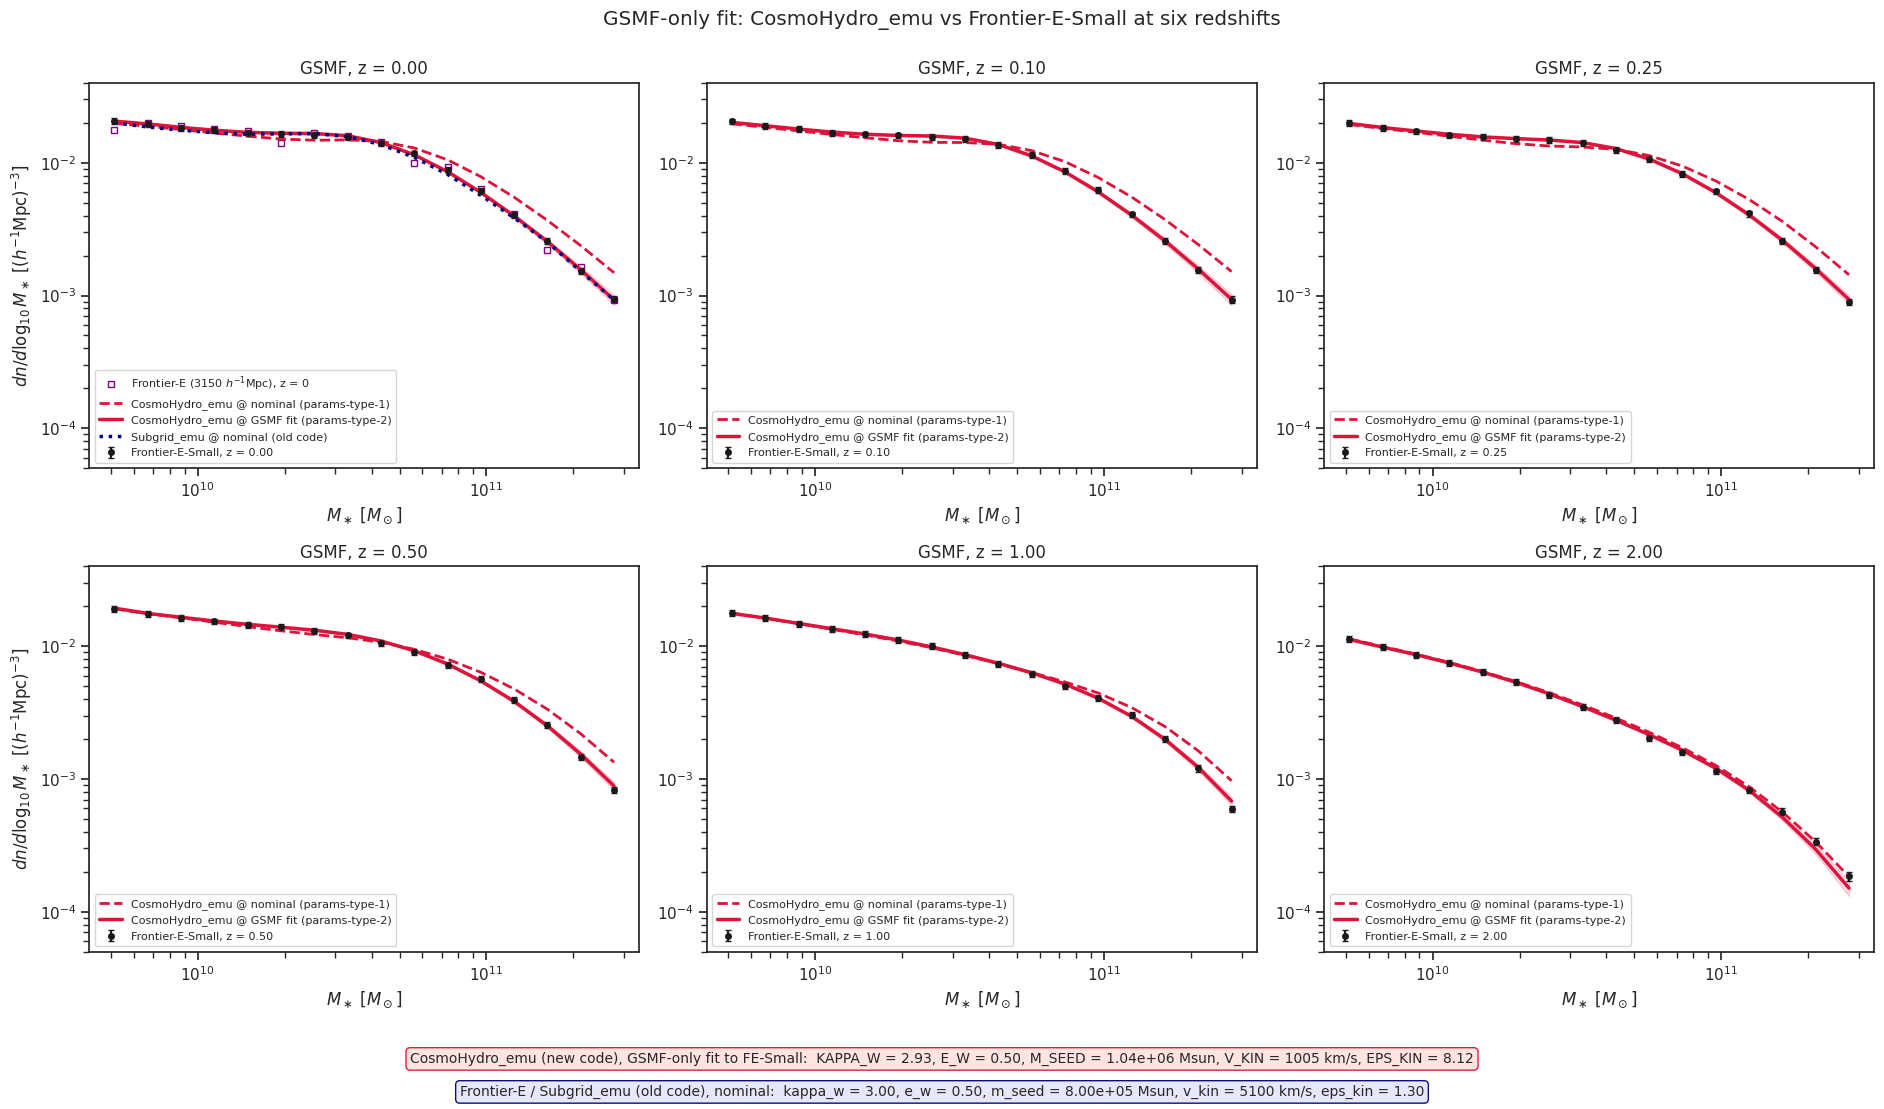

chi2/N of the six GSMFs: nominal 16.9 17.1 13.9 11.7 8.3 0.7 | GSMF fit 0.1 0.1 0.1 0.2 0.4 1.1


In [13]:
def read_pk_ratio_fes(step):
    a = np.loadtxt(f'{FES}/pk_hydro/m000p.pk.{step}'); b = np.loadtxt(f'{FES}/pk_gravonly/m000p.pk.{step}')
    return a[:, 0], a[:, 1] / np.interp(np.log(a[:, 0]), np.log(b[:, 0]), b[:, 1])
sg = {n: sge.load_emulator(n) for n in ['GSMF', 'Pk', 'fGas', 'CGD', 'CSFR']}
sgx = {n: np.asarray(sge.get_x_grid(n)[0]) for n in sg}

fig, axes = plt.subplots(2, 3, figsize=(19, 11)); axes = axes.ravel()
for ax, (step, t) in zip(axes, G6.items()):
    ax.errorbar(x_g[t['ok']], t['y'][t['ok']], yerr=(t['y'] * t['sig'] * np.log(10))[t['ok']], fmt='o', ms=4, color='k', capsize=2, label=f'Frontier-E-Small, z = {t["z"]:.2f}')
    if step == 624: ax.plot(x_g, T['GSMF z=0']['y'], 's', ms=4, mfc='none', color='purple', label='Frontier-E (3150 $h^{-1}$Mpc), z = 0')
    ax.plot(x_g, emu('GSMF', P5_NOM, t['z'])[0], color='crimson', ls='--', lw=2, label='CosmoHydro_emu @ nominal (params-type-1)')
    m, s = emu('GSMF', P5_G, t['z']); ax.plot(x_g, m, color='crimson', lw=2.5, label='CosmoHydro_emu @ GSMF fit (params-type-2)'); ax.fill_between(x_g, m - 2*s, m + 2*s, color='crimson', alpha=0.15)
    if step == 624: ax.plot(x_g, sg['GSMF'].predict(list(P5_NOM))[0], color='navy', ls=':', lw=2.5, label='Subgrid_emu @ nominal (old code)')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(5e-5, 4e-2); ax.set_title(f'GSMF, z = {t["z"]:.2f}'); ax.set_xlabel(r'$M_\ast\;[M_\odot]$'); ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$'); axes[3].set_ylabel(r'$dn/d\log_{10}M_\ast\;[(h^{-1}{\rm Mpc})^{-3}]$')
fig.text(0.5, 0.035, TXT_CAP, ha='center', va='bottom', fontsize=10, bbox=BOX_CAP); fig.text(0.5, 0.005, TXT_LOW, ha='center', va='bottom', fontsize=10, bbox=BOX_LOW)
plt.suptitle('GSMF-only fit: CosmoHydro_emu vs Frontier-E-Small at six redshifts', y=0.995); plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()
print('chi2/N of the six GSMFs: nominal', ' '.join(f'{np.nansum(((L10(emu("GSMF", P5_NOM, t["z"])[0]) - L10(t["y"])) / t["sig"])[t["ok"]]**2) / t["ok"].sum():.1f}' for t in G6.values()),
      '| GSMF fit', ' '.join(f'{np.nansum(((L10(emu("GSMF", P5_G, t["z"])[0]) - L10(t["y"])) / t["sig"])[t["ok"]]**2) / t["ok"].sum():.1f}' for t in G6.values()))

### Predictions at the GSMF-only point for the statistics that were *not* fitted

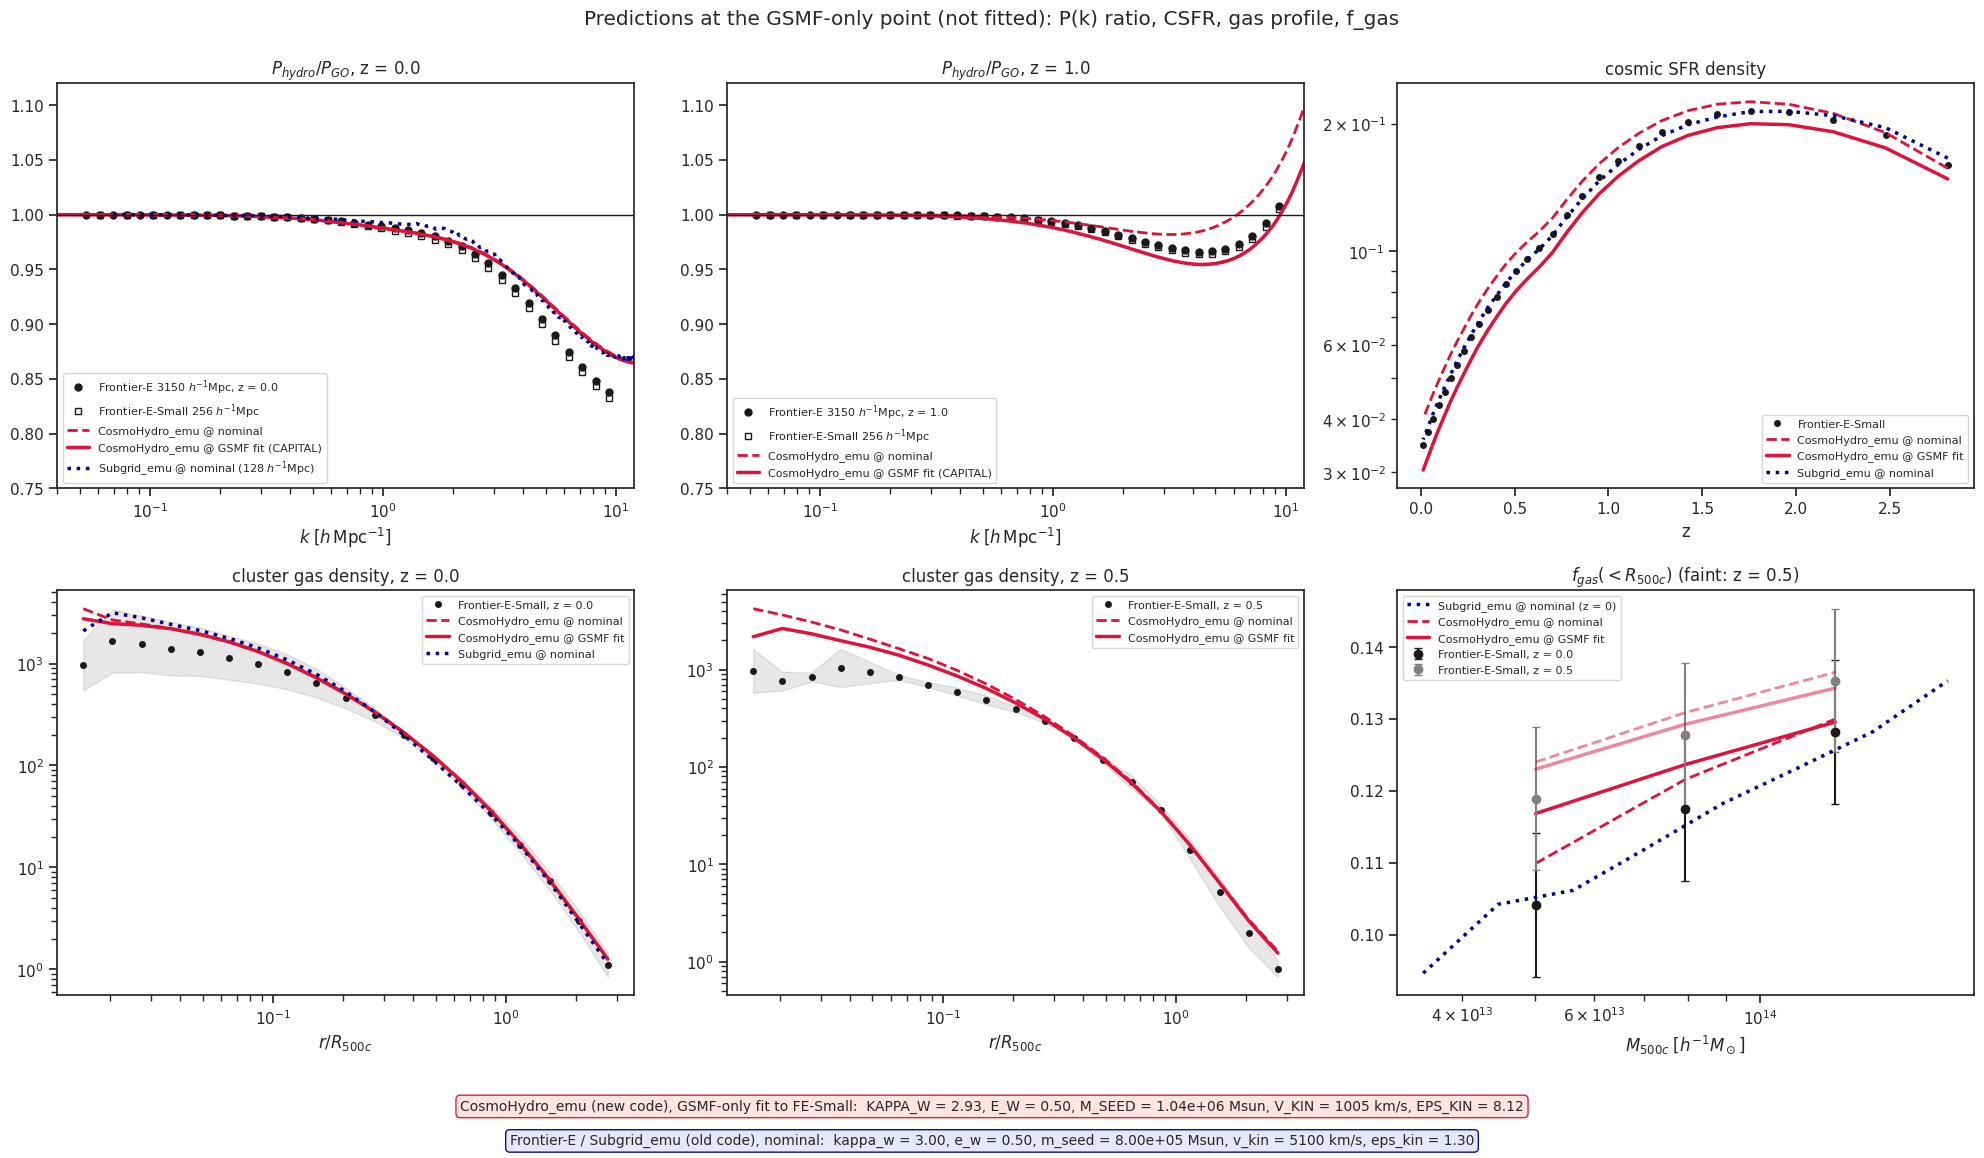

chi2/N at the three points (fitted set of section 1 plus held-out targets):
chi2/N                  nominal  GSMF-only fit joint fit (§4)
GSMF z=0                  41.17           6.26           5.55
GSMF z=0.5                 9.59           0.19           0.43
GSMF z=1.0                 6.79           0.34           0.75
Pk-ratio z=0.0             1.11           0.87           0.18
Pk-ratio z=0.5             2.62           0.26           0.77
Pk-ratio z=1.0             1.40           0.44           0.32
Pk-ratio z=2.0             0.04           0.87           0.68
fGas z=0                   0.18           0.65           0.27
CGD z=0                    9.55           4.60           2.51
CSFR                       0.95           1.03           1.20
GSMF z=0.1                13.99           0.07           0.35
GSMF z=0.25               11.71           0.08           0.42
GSMF z=2.0                 0.74           0.68           0.79
Pk-ratio z=0.25            2.09           0.24          

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11.5)); axes = axes.ravel()
# P(k) ratio at z = 0 and z = 1: survey-scale (filled) and FE-Small (open) to show the box-size effect
for ax, step in zip(axes[:2], [624, 310]):
    z = STEP_Z[step]; k, r = read_pk_ratio_fe(step); kk, rr = read_pk_ratio_fes(step)
    ax.plot(KC, to_kbins(k, r), 'o', ms=5, color='k', label=f'Frontier-E 3150 $h^{{-1}}$Mpc, z = {z}')
    ax.plot(KC, to_kbins(kk, rr), 's', ms=5, mfc='none', color='k', label='Frontier-E-Small 256 $h^{-1}$Mpc')
    ax.plot(k_emu, emu('Pk-ratio', P5_NOM, z)[0], color='crimson', ls='--', lw=2, label='CosmoHydro_emu @ nominal')
    ax.plot(k_emu, emu('Pk-ratio', P5_G, z)[0], color='crimson', lw=2.5, label='CosmoHydro_emu @ GSMF fit (CAPITAL)')
    if step == 624: ax.plot(sgx['Pk'], sg['Pk'].predict(list(P5_NOM))[0], color='navy', ls=':', lw=2.5, label='Subgrid_emu @ nominal (128 $h^{-1}$Mpc)')
    ax.axhline(1, color='k', lw=1); ax.set_xscale('log'); ax.set_xlim(0.04, 12); ax.set_ylim(0.75, 1.12); ax.set_title(rf'$P_{{hydro}}/P_{{GO}}$, z = {z}'); ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$'); ax.legend(fontsize=8, loc='lower left')
# CSFR
ax = axes[2]; ax.plot(1/AC - 1, T['CSFR']['y'], 'o', ms=4, color='k', label='Frontier-E-Small')
ax.plot(1/AC - 1, model('CSFR', P5_NOM, 0.0)[0], color='crimson', ls='--', lw=2, label='CosmoHydro_emu @ nominal'); ax.plot(1/AC - 1, model('CSFR', P5_G, 0.0)[0], color='crimson', lw=2.5, label='CosmoHydro_emu @ GSMF fit')
ax.plot(1/AC - 1, to_abins(sgx['CSFR'], sg['CSFR'].predict(list(P5_NOM))[0]), color='navy', ls=':', lw=2.5, label='Subgrid_emu @ nominal')
ax.set_yscale('log'); ax.set_title('cosmic SFR density'); ax.set_xlabel('z'); ax.legend(fontsize=8)
# CGD z = 0 and 0.5
for ax, (kname, z) in zip(axes[3:5], [('CGD z=0', 0.0), ('CGD z=0.5', 0.4987)]):
    t = T[kname]; ax.plot(XG['CGD'], t['y'], 'o', ms=4, color='k', label=f'Frontier-E-Small, z = {z:.1f}'); ax.fill_between(XG['CGD'], t['lo'], t['hi'], color='k', alpha=0.1)
    ax.plot(XG['CGD'], emu('CGD', P5_NOM, z)[0], color='crimson', ls='--', lw=2, label='CosmoHydro_emu @ nominal'); ax.plot(XG['CGD'], emu('CGD', P5_G, z)[0], color='crimson', lw=2.5, label='CosmoHydro_emu @ GSMF fit')
    if z == 0.0: ax.plot(sgx['CGD'], sg['CGD'].predict(list(P5_NOM))[0], color='navy', ls=':', lw=2.5, label='Subgrid_emu @ nominal')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title(rf'cluster gas density, z = {z:.1f}'); ax.set_xlabel(r'$r/R_{500c}$'); ax.legend(fontsize=8)
# fGas z = 0 and 0.5
ax = axes[5]
for kname, z, c in [('fGas z=0', 0.0, 'k'), ('fGas z=0.5', 0.5, 'gray')]:
    t = T[kname]; ax.errorbar(XG['fGas'], t['y'], yerr=t['sig'], fmt='o', ms=6, color=c, capsize=3, label=f'Frontier-E-Small, z = {z}')
    ax.plot(XG['fGas'], emu('fGas', P5_NOM, z)[0], color='crimson', ls='--', lw=2, alpha=1 if z == 0 else 0.5); ax.plot(XG['fGas'], emu('fGas', P5_G, z)[0], color='crimson', lw=2.5, alpha=1 if z == 0 else 0.5)
ax.plot(sgx['fGas'], sg['fGas'].predict(list(P5_NOM))[0], color='navy', ls=':', lw=2.5, label='Subgrid_emu @ nominal (z = 0)')
ax.plot([], [], color='crimson', ls='--', lw=2, label='CosmoHydro_emu @ nominal'); ax.plot([], [], color='crimson', lw=2.5, label='CosmoHydro_emu @ GSMF fit')
ax.set_xscale('log'); ax.set_title(r'$f_{gas}(<R_{500c})$ (faint: z = 0.5)'); ax.set_xlabel(r'$M_{500c}\;[h^{-1}M_\odot]$'); ax.legend(fontsize=8)
fig.text(0.5, 0.035, TXT_CAP, ha='center', va='bottom', fontsize=10, bbox=BOX_CAP); fig.text(0.5, 0.005, TXT_LOW, ha='center', va='bottom', fontsize=10, bbox=BOX_LOW)
plt.suptitle('Predictions at the GSMF-only point (not fitted): P(k) ratio, CSFR, gas profile, f_gas', y=0.995); plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

print('chi2/N at the three points (fitted set of section 1 plus held-out targets):')
chi2_table({'nominal': P5_NOM, 'GSMF-only fit': P5_G, 'joint fit (§4)': P5_FIT}, keys=list(T));

## Notes

**Result.** With the cosmology fixed to Frontier-E, CosmoHydro_emu reproduces the Frontier-E
family once the subgrid parameters are re-interpreted. The joint objective drops from
J = 73 (nominal point) to J = 12.7 (best fit) and the held-out targets from 42 to 4.8, so the
effective point is not an over-fit to the fitted statistics.

| parameter | nominal (Frontier-E) | joint best fit | posterior median (16-84 %) |
|---|---|---|---|
| κ_w | 3.0 | 3.01 | 2.96 (2.81-3.11) |
| e_w | 0.5 | 0.55 | 0.52 (0.48-0.56) |
| M_seed / 10⁶ M☉ | 0.8 | 0.94 | 1.17 (1.03-1.26) |
| v_kin / 10⁴ km s⁻¹ | 0.51 | 0.35 | 0.67 (0.40-1.02) |
| ε_kin / 10 | 0.13 | 1.20 (box edge) | 0.25 (0.19-0.60) |

- **The wind parameters barely move** (κ_w, e_w within 10 % of nominal). What changes is the
  **AGN sector**: the new code needs a larger seed mass and stronger kinetic feedback to
  quench massive galaxies the way the old code did with M_seed = 0.8×10⁶, ε_kin = 1.3. That is
  exactly the mechanism nb7 identified (lighter black holes, later quenching in the new build).
- **Degeneracy.** M_seed, v_kin and ε_kin are strongly correlated (ρ = −0.77 between M_seed and
  ε_kin, −0.61 between v_kin and ε_kin): the fitted statistics constrain the *amount* of AGN
  quenching, not how it is split between seed mass, jet velocity and efficiency. The joint
  optimiser ran ε_kin to the edge of the training box (1.2) with a moderate M_seed; the bulk of
  the posterior sits at ε_kin ≈ 0.25 with M_seed ≈ 1.2×10⁶, at only slightly worse J (15.7 vs
  12.7). **Use the posterior median as the interior effective point** unless a statistic that
  breaks the degeneracy (BH masses, cluster profiles at several z) is added; both are stored in
  `../data_sims/cosmohydro_400/effective_frontier_e_point.npz` with the posterior samples.
- **Per statistic.** GSMF (three redshifts) and CSFR want the AGN-driven suppression of the
  massive end; the P(k) ratio alone prefers weaker winds (κ_w ≈ 2.1, e_w ≈ 0.37) and would
  spoil the GSMF (χ²/N = 18); f_gas alone is unconstraining. The joint fit reconciles them:
  every fitted target ends at χ²/N ≤ 2.5 except the z = 0 survey-scale GSMF (5.5, against a
  3 % error floor; the residual is ≤ 0.03 dex).
- **What remains imperfect.** The z = 0 cluster gas-density profile inside 0.1 R₅₀₀c is still
  25-40 % high (χ²/N 2.5, was 9.6), the z = 0 P(k) suppression at k = 5-10 h Mpc⁻¹ is
  reproduced to 1-2 %, f_gas is 0.005-0.01 low, and CSFR is 5-10 % low at z < 1 (the same
  fraction that the new build puts into galaxies rather than forming, nb7). None of these can
  be fixed by the five subgrid parameters alone: they are the residual model difference.
- **Translation check (section 7, last figure).** CosmoHydro_emu at the effective point lies
  on top of Subgrid_emu at the nominal point for the z = 0 GSMF and P(k) ratio, i.e. the
  effective point *is* the old model's Frontier-E point expressed in the new model's
  parameters.
- **Caveats.** Cosmology dependence is assumed unaffected by the code change (only the
  subgrid parameters were refitted). The effective point is specific to the Frontier-E
  target; a different old-code run would map to a different new-code point, so the map is
  not a global parameter transformation. Error floors (3-10 %) are judgement calls; they set
  the width of the posterior but not its centre.

### GSMF-only fit (section 8)

- Fitting the Frontier-E-Small GSMF alone at six redshifts gives χ²/N = 0.25 (from 9.5 at the
  nominal point; every redshift ≤ 0.4 except z = 2 at 1.1). The result, in the new-code
  (capital) parameters: KAPPA_W = 2.93, E_W = 0.50, M_SEED = 1.04×10⁶ M☉, V_KIN = 1005 km/s
  (lower box edge), EPS_KIN = 8.1, against the old-code nominal kappa_w = 3.0, e_w = 0.5,
  m_seed = 8×10⁵, v_kin = 5100, eps_kin = 1.3. Posterior (16-84 %): KAPPA_W 2.75-3.41,
  E_W 0.45-0.60, M_SEED 0.90-1.44×10⁶, V_KIN 2700-10100 km/s, EPS_KIN 1.9-10.2.
- **The wind parameters again stay at their old-code values** (E_W = 0.50 exactly, KAPPA_W
  within 2 %), even though only the GSMF is fitted and the wind sensitivity of the GSMF is
  0.1-0.3 dex across the box. The GSMF of the new build differs from the old one only above
  ~4×10¹⁰ M☉ (nb7), and that is the AGN regime: a heavier seed with a stronger, slower jet
  does the quenching that the old build achieved with lighter seeds and a fast, inefficient
  jet. The star-formation-law and enrichment changes are absorbed by wind self-regulation
  (stellar mass at fixed halo mass is set by the mass loading, not by the SF efficiency) and
  by the 5 % error floor (the retained-mass change is +6.6 %).
- The GSMF-only point is degenerate along M_SEED-V_KIN-EPS_KIN (the GSMF measures the
  quenching, not its split); the optimiser picked the slow-jet corner, the posterior median
  sits at V_KIN ≈ 6900 km/s, EPS_KIN ≈ 6.2.
- **Predictions at that point** (not fitted): the survey-scale P(k) ratio is reproduced
  about as well as at the nominal point at z = 0 (χ²/N 0.9 vs 1.1) and better at z = 0.5-1
  (0.3-0.4 vs 1.4-2.6); the gas-density profile improves (χ²/N 9.6 → 4.6 at z = 0,
  13 → 4.1 at z = 0.5); f_gas is 0.005-0.01 low (0.65 vs 0.18); CSFR unchanged (1.0). The
  P(k) panels also show the box-size effect the joint fit was exposed to: the 256 h⁻¹Mpc
  Frontier-E-Small suppression differs from the 3150 h⁻¹Mpc one by 1-3 % at k = 1-5 h Mpc⁻¹,
  and Subgrid_emu (128 h⁻¹Mpc) differs further, so P(k) ratios from different box sizes
  should not be matched at the percent level with subgrid parameters alone.
- Stored in `../data_sims/cosmohydro_400/effective_frontier_e_point_gsmf_only.npz`.
